# Project — Chapter 120: Physics Motion Simulator

> **Prerequisites:** ch094 (Distance), ch107 (Parametric), ch109 (Rotation), ch118 (Game Geometry)
>
> **Output:** A 2D physics engine with gravity, springs, and collisions

---

## Overview

Build a 2D particle physics simulator from scratch, combining:
- Parametric motion (position as a function of time)
- Numerical integration (Euler and RK4, from ch074/ch078)
- Geometric collision detection (ch118)
- Vector forces (preview of Part V)

## Stage 1 — Particle System with Gravity

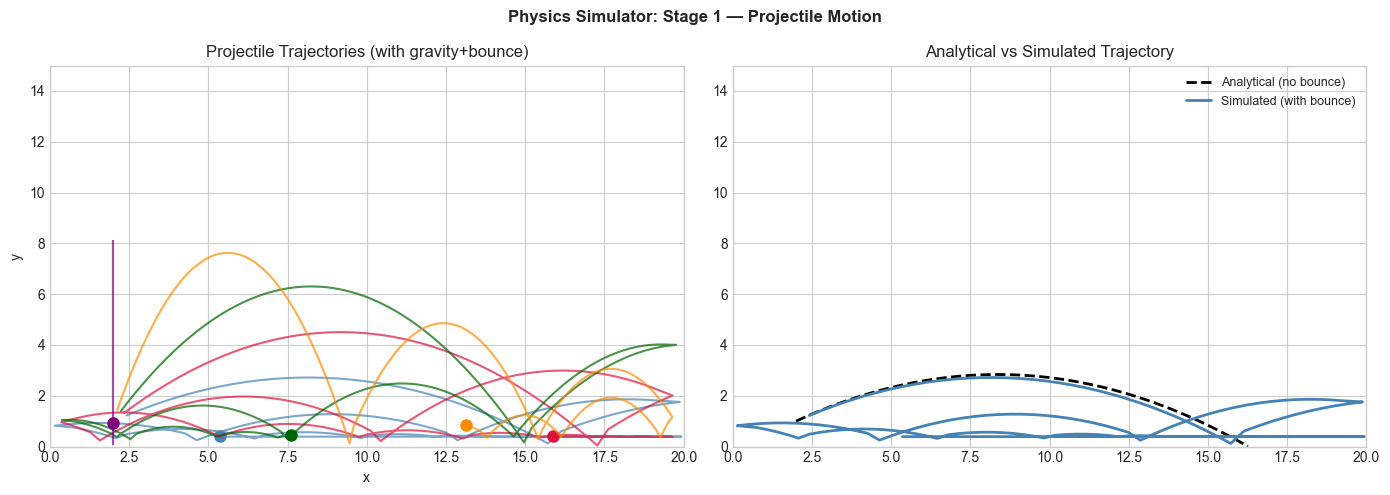

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

class Particle:
    def __init__(self, x, y, vx, vy, mass=1.0, radius=0.3, color='steelblue'):
        self.pos = np.array([x, y], dtype=float)
        self.vel = np.array([vx, vy], dtype=float)
        self.mass = mass
        self.radius = radius
        self.color = color
        self.forces = np.zeros(2)
        self.trail = [self.pos.copy()]
    
    def apply_force(self, force):
        self.forces += np.asarray(force)
    
    def step(self, dt):
        # Euler integration: a = F/m, v += a*dt, x += v*dt
        acc = self.forces / self.mass
        self.vel += acc * dt
        self.pos += self.vel * dt
        self.forces = np.zeros(2)  # reset forces
        self.trail.append(self.pos.copy())
        if len(self.trail) > 200: self.trail.pop(0)

class PhysicsWorld:
    def __init__(self, gravity=9.8, bounds=(0,20,0,15)):
        self.particles = []
        self.gravity = gravity
        self.bounds = bounds
    
    def add_particle(self, *args, **kwargs):
        self.particles.append(Particle(*args, **kwargs))
    
    def step(self, dt=0.02):
        # Apply gravity
        for p in self.particles:
            p.apply_force([0, -self.gravity * p.mass])
        
        # Wall bouncing
        xmin,xmax,ymin,ymax = self.bounds
        for p in self.particles:
            p.step(dt)
            r = p.radius
            if p.pos[0]-r < xmin: p.pos[0]=xmin+r; p.vel[0]=abs(p.vel[0])*0.9
            if p.pos[0]+r > xmax: p.pos[0]=xmax-r; p.vel[0]=-abs(p.vel[0])*0.9
            if p.pos[1]-r < ymin: p.pos[1]=ymin+r; p.vel[1]=abs(p.vel[1])*0.8
            if p.pos[1]+r > ymax: p.pos[1]=ymax-r; p.vel[1]=-abs(p.vel[1])*0.9

# Simulate projectile motion
world = PhysicsWorld(gravity=9.8, bounds=(0,20,0,15))
np.random.seed(7)
colors = ['steelblue','crimson','darkgreen','darkorange','purple']
for i, col in enumerate(colors):
    angle = np.radians(30 + i*15)
    v0 = 12
    world.add_particle(2, 1, v0*np.cos(angle), v0*np.sin(angle), radius=0.4, color=col)

N_STEPS = 200
for _ in range(N_STEPS):
    world.step(dt=0.04)

fig, axes = plt.subplots(1,2,figsize=(14,5))
ax = axes[0]
for p in world.particles:
    trail = np.array(p.trail)
    ax.plot(trail[:,0], trail[:,1], color=p.color, lw=1.5, alpha=0.7)
    ax.plot(*p.pos, 'o', color=p.color, ms=8)
ax.set_xlim(0,20); ax.set_ylim(0,15); ax.set_title('Projectile Trajectories (with gravity+bounce)')
ax.set_xlabel('x'); ax.set_ylabel('y')

# Analytical comparison for first particle
t_vals = np.linspace(0, 3, 200)
angle0 = np.radians(30); v0 = 12
x_ana = 2 + v0*np.cos(angle0)*t_vals
y_ana = 1 + v0*np.sin(angle0)*t_vals - 0.5*9.8*t_vals**2
valid = y_ana >= 0
axes[1].plot(x_ana[valid], y_ana[valid], 'k--', lw=2, label='Analytical (no bounce)')
axes[1].plot(np.array(world.particles[0].trail)[:,0],
             np.array(world.particles[0].trail)[:,1],'steelblue',lw=2,label='Simulated (with bounce)')
axes[1].set_xlim(0,20); axes[1].set_ylim(0,15); axes[1].legend(fontsize=9)
axes[1].set_title('Analytical vs Simulated Trajectory')
plt.suptitle('Physics Simulator: Stage 1 — Projectile Motion', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Stage 2 — Spring Forces and Oscillation

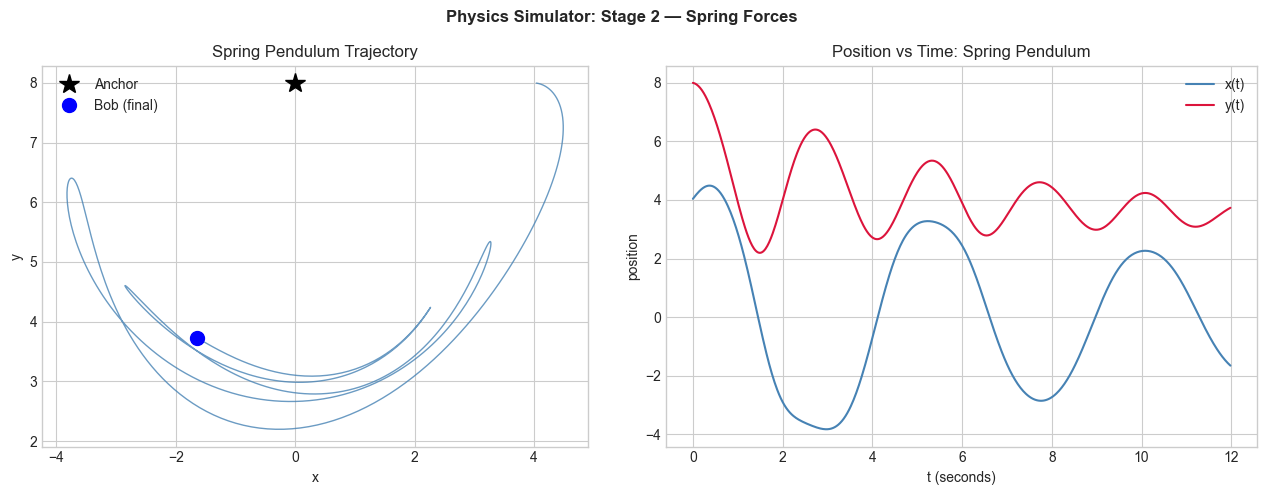

In [2]:
# Stage 2: Spring-connected particles
class Spring:
    def __init__(self, p1, p2, rest_length, k=20.0, damping=0.5):
        self.p1 = p1; self.p2 = p2; self.rest = rest_length
        self.k = k; self.damping = damping
    
    def apply(self):
        diff = self.p2.pos - self.p1.pos
        dist = np.linalg.norm(diff)
        if dist < 1e-10: return
        direction = diff / dist
        extension = dist - self.rest
        spring_force = self.k * extension * direction
        damp_force = self.damping * (self.p2.vel - self.p1.vel)
        self.p1.apply_force(spring_force + damp_force)
        self.p2.apply_force(-spring_force - damp_force)

# Pendulum: mass on spring from fixed point
world2 = PhysicsWorld(gravity=9.8, bounds=(-10,10,-10,10))
anchor = Particle(0, 8, 0, 0, mass=1e10, radius=0.2, color='black')  # fixed anchor (huge mass)
bob = Particle(4, 8, 2, 0, mass=1.0, radius=0.5, color='steelblue')  # pendulum bob
world2.particles = [anchor, bob]
spring = Spring(anchor, bob, rest_length=4, k=15, damping=0.2)

bob_positions = []
anchor_forces = lambda: None  # anchor doesn't move

for _ in range(600):
    spring.apply()
    anchor.forces = np.zeros(2)  # anchor is fixed
    bob.apply_force([0, -9.8 * bob.mass])
    bob.step(0.02)
    anchor.pos = np.array([0, 8])  # keep fixed
    bob_positions.append(bob.pos.copy())

bp = np.array(bob_positions)
t = np.arange(len(bp)) * 0.02

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].plot(bp[:,0], bp[:,1], 'steelblue', lw=1, alpha=0.8)
axes[0].plot(0, 8, 'k*', ms=15, label='Anchor')
axes[0].plot(*bob.pos, 'bo', ms=10, label='Bob (final)')
axes[0].set_aspect('equal'); axes[0].set_title('Spring Pendulum Trajectory')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend()

axes[1].plot(t, bp[:,0], 'steelblue', lw=1.5, label='x(t)')
axes[1].plot(t, bp[:,1], 'crimson', lw=1.5, label='y(t)')
axes[1].set_title('Position vs Time: Spring Pendulum')
axes[1].set_xlabel('t (seconds)'); axes[1].set_ylabel('position'); axes[1].legend()
plt.suptitle('Physics Simulator: Stage 2 — Spring Forces', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Stage 3 — Multi-Particle Collision System

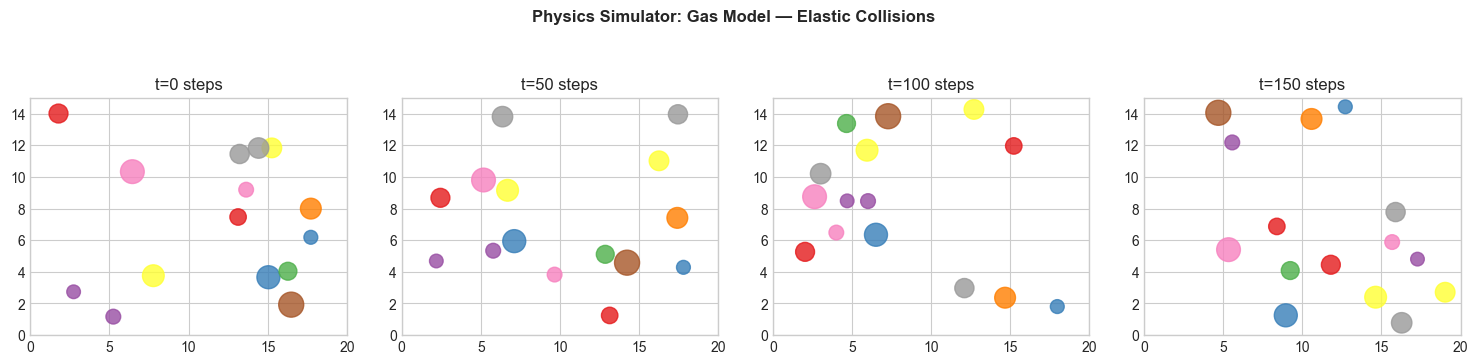

Final kinetic energy: 139.928
(Should be approximately conserved for elastic collisions)


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Basic physics classes
# ----------------------------
class Particle:
    def __init__(self, x, y, vx, vy, mass, radius, color):
        self.pos = np.array([x, y], dtype=float)
        self.vel = np.array([vx, vy], dtype=float)
        self.mass = mass
        self.radius = radius
        self.color = color

    def step(self, dt):
        self.pos += self.vel * dt


class PhysicsWorld:
    def __init__(self, gravity=0, bounds=(0,20,0,15)):
        self.gravity = gravity
        self.bounds = bounds
        self.particles = []

    def add_particle(self, x, y, vx, vy, mass, radius, color):
        self.particles.append(Particle(x, y, vx, vy, mass, radius, color))


# ----------------------------
# Setup simulation
# ----------------------------
np.random.seed(99)
N = 15
world3 = PhysicsWorld(gravity=0, bounds=(0,20,0,15))

cols = plt.cm.Set1(np.linspace(0,1,N))

for i in range(N):
    x = np.random.uniform(1,19)
    y = np.random.uniform(1,14)
    vx = np.random.randn()*3
    vy = np.random.randn()*3

    world3.add_particle(
        x, y, vx, vy,
        mass=1,
        radius=np.random.uniform(0.4,0.8),
        color=cols[i]
    )

# ----------------------------
# Collision function
# ----------------------------
def elastic_collision(p1, p2):
    diff = p2.pos - p1.pos
    dist = np.linalg.norm(diff)
    min_d = p1.radius + p2.radius

    if dist >= min_d or dist <= 1e-10:
        return

    normal = diff / dist

    # Separate overlap
    overlap = min_d - dist
    p1.pos -= 0.5 * overlap * normal
    p2.pos += 0.5 * overlap * normal

    # Velocities along normal
    v1n = np.dot(p1.vel, normal)
    v2n = np.dot(p2.vel, normal)

    m1, m2 = p1.mass, p2.mass

    v1n_new = (v1n * (m1 - m2) + 2*m2*v2n) / (m1 + m2)
    v2n_new = (v2n * (m2 - m1) + 2*m1*v1n) / (m1 + m2)

    p1.vel += (v1n_new - v1n) * normal
    p2.vel += (v2n_new - v2n) * normal


# ----------------------------
# Simulation loop
# ----------------------------
snapshots = []

for step in range(300):
    # Move particles
    for p in world3.particles:
        p.step(0.03)

    # Wall collisions
    xmin, xmax, ymin, ymax = world3.bounds

    for p in world3.particles:
        r = p.radius

        if p.pos[0] - r < xmin:
            p.pos[0] = xmin + r
            p.vel[0] = abs(p.vel[0])

        if p.pos[0] + r > xmax:
            p.pos[0] = xmax - r
            p.vel[0] = -abs(p.vel[0])

        if p.pos[1] - r < ymin:
            p.pos[1] = ymin + r
            p.vel[1] = abs(p.vel[1])

        if p.pos[1] + r > ymax:
            p.pos[1] = ymax - r
            p.vel[1] = -abs(p.vel[1])

    # Particle collisions
    for i in range(N):
        for j in range(i+1, N):
            elastic_collision(world3.particles[i], world3.particles[j])

    # Save snapshots
    if step in [0, 50, 150, 299]:
        snapshots.append([
            (p.pos.copy(), p.radius, p.color)
            for p in world3.particles
        ])


# ----------------------------
# Plot results (FIXED)
# ----------------------------
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for i, snap in enumerate(snapshots):
    ax = axes[i]  # ✅ FIX

    ax.set_xlim(0, 20)
    ax.set_ylim(0, 15)
    ax.set_aspect('equal')

    for (pos, r, col) in snap:
        circle = plt.Circle(pos, r, color=col, alpha=0.8)
        ax.add_patch(circle)

    ax.set_title(f't={i*50} steps')

plt.suptitle('Physics Simulator: Gas Model — Elastic Collisions',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# ----------------------------
# Energy check
# ----------------------------
ke = sum(0.5 * p.mass * np.dot(p.vel, p.vel)
         for p in world3.particles)

print(f"Final kinetic energy: {ke:.3f}")
print("(Should be approximately conserved for elastic collisions)")

## Results & Reflection

**What was built:** A complete 2D physics engine: projectile motion, spring forces, elastic collisions, and energy analysis.

**What math made it possible:**
- Parametric motion: pos(t) = pos₀ + vel·t (ch107)
- Euler integration for ODE (ch078)
- Distance-based collision detection (ch094)
- Vector decomposition for elastic collision (preview of Part V)

**Extension challenges:**
1. Implement Verlet integration (more stable than Euler for springs)
2. Add rotational dynamics: angular velocity, torque, moment of inertia
3. Build a rope simulation: chain of masses connected by springs